#   Iris Flower Classification

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load the Dataset

In [5]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving archive (1).zip to archive (1).zip
User uploaded file "archive (1).zip" with length 1307 bytes


Read the CSV File

In [7]:
import zipfile

zip_path = "archive (1).zip" # This file was uploaded to /content/
extract_dir = "iris_dataset"

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

df = pd.read_csv(f"{extract_dir}/Iris.csv")

In [8]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Understand the Dataset

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [10]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [11]:
print(df['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Data Visualization

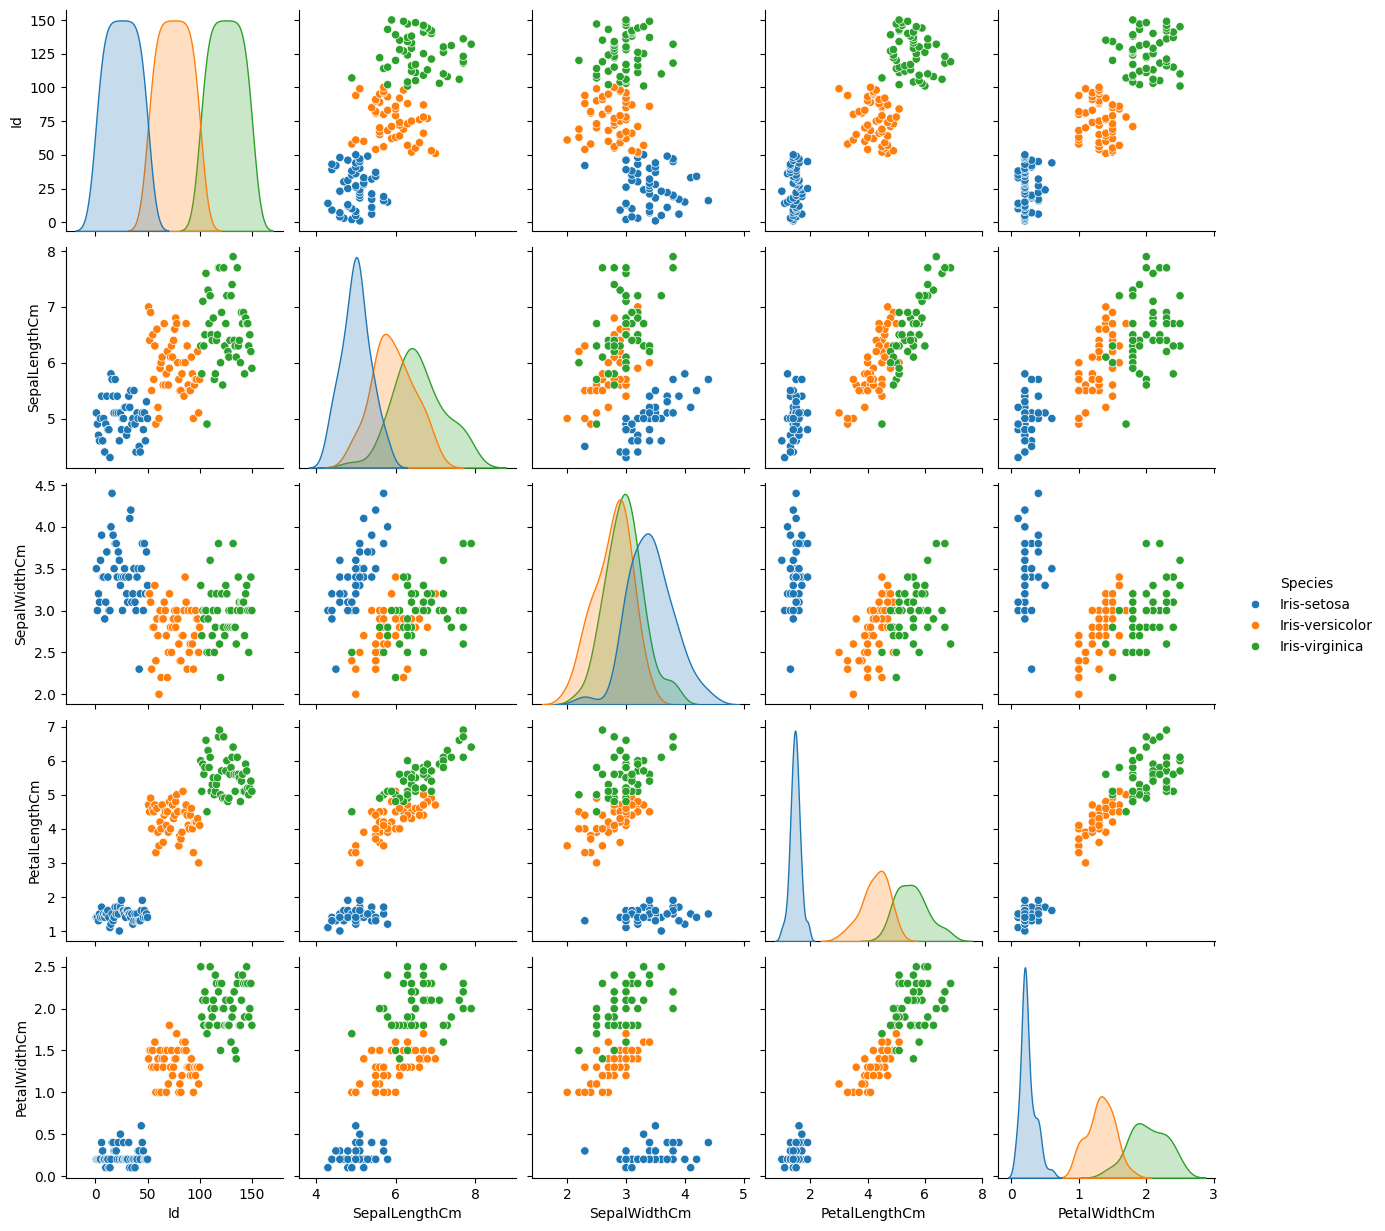

In [12]:
sns.pairplot(df, hue='Species')
plt.show()

Heatmap

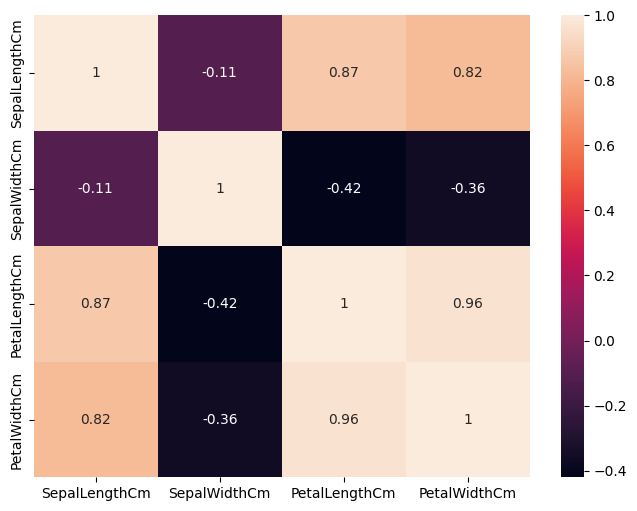

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('Id', axis=1).corr(numeric_only=True), annot=True)
plt.show()

Prepare Data

In [19]:
df = df.drop('Id', axis=1, errors='ignore')

Features (X) and Target (y)

In [20]:
X = df.drop('Species', axis=1)
y = df['Species']

Split Dataset

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Machine Learning Model

In [23]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Make Predictions

In [24]:
y_pred = model.predict(X_test)

Check Accuracy

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


Classification Report

In [26]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Confusion Matrix

In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


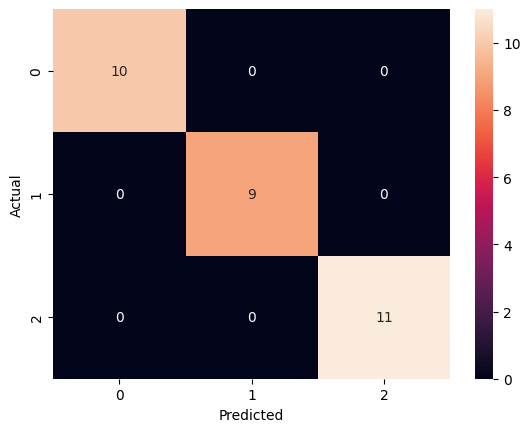

In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Predict New Flower

In [28]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Multiple Algorithms

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(name, ":", accuracy)

Logistic Regression : 1.0
Decision Tree : 1.0
Random Forest : 1.0
KNN : 1.0


Sepal Length vs Sepal Width

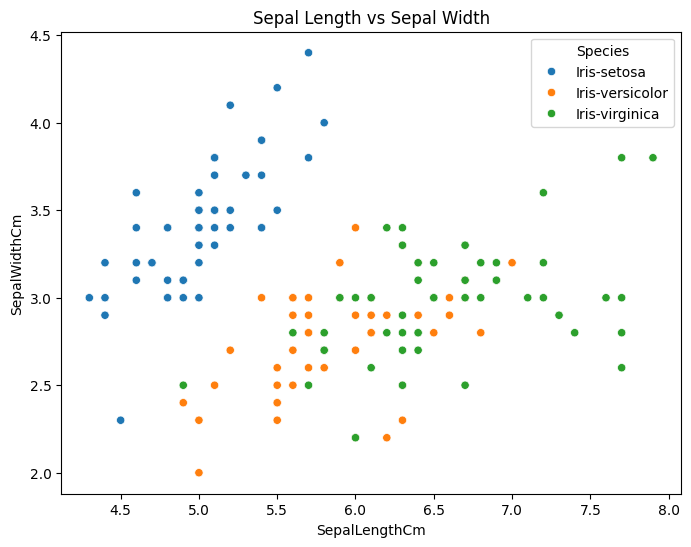

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Species',
    data=df
)

plt.title("Sepal Length vs Sepal Width")
plt.show()

Petal Length vs Petal Width

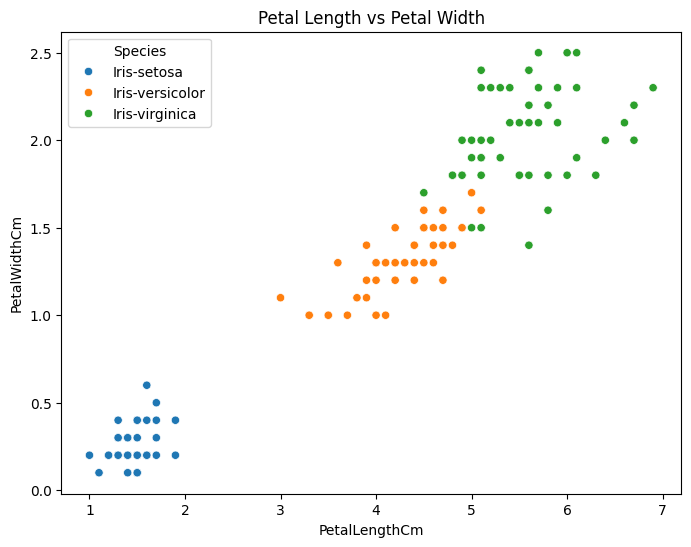

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    data=df
)

plt.title("Petal Length vs Petal Width")
plt.show()

Histogram


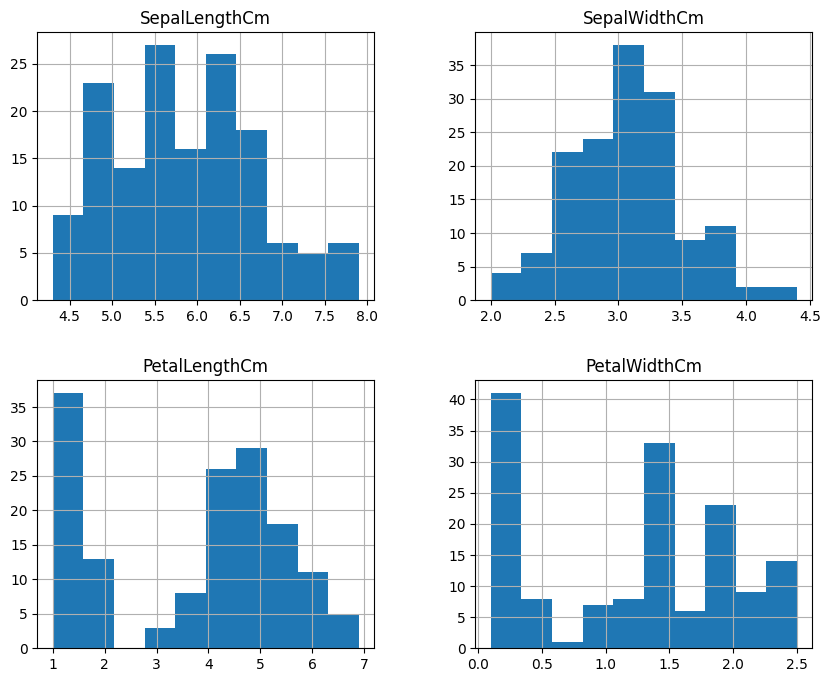

In [34]:
df.hist(figsize=(10,8))
plt.show()

Multiple Box Plots Together

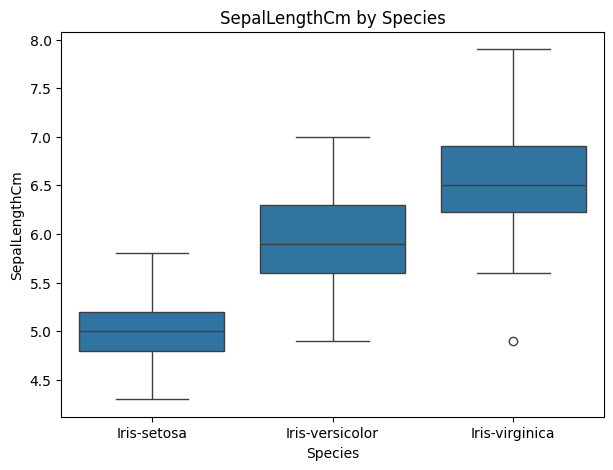

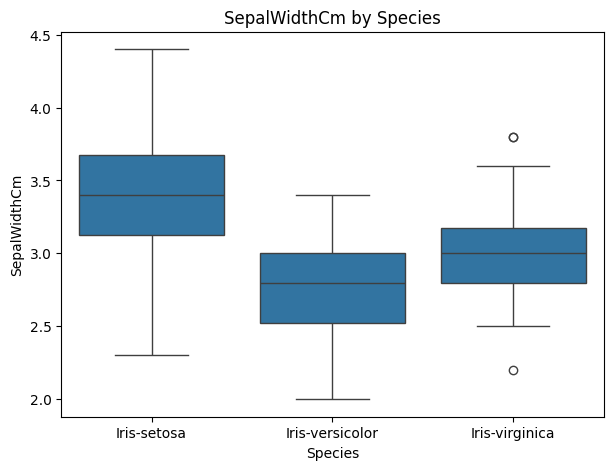

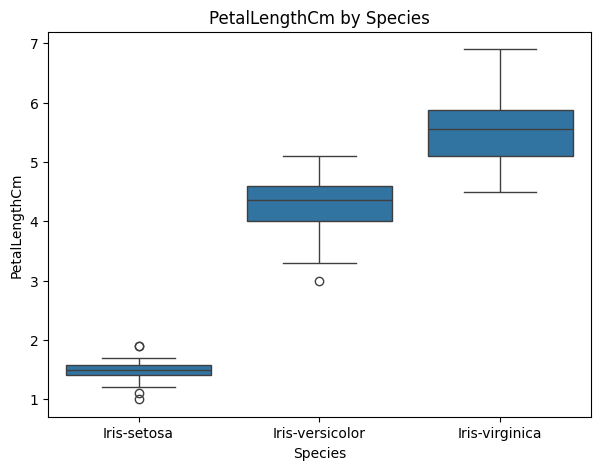

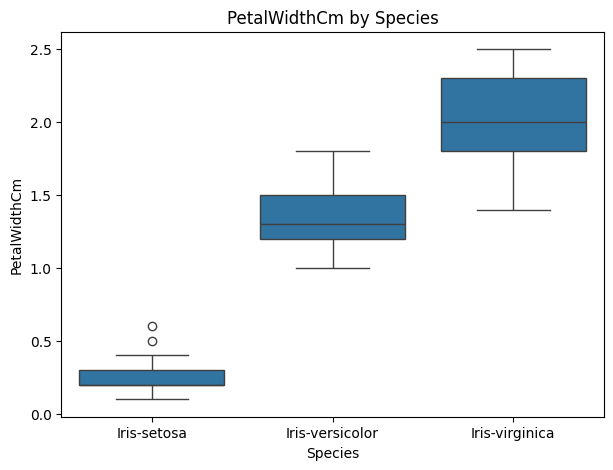

In [35]:
features = ['SepalLengthCm', 'SepalWidthCm',
            'PetalLengthCm', 'PetalWidthCm']

for feature in features:
    plt.figure(figsize=(7,5))

    sns.boxplot(x='Species', y=feature, data=df)

    plt.title(f'{feature} by Species')
    plt.show()

In [36]:
print(name, ":", accuracy)

KNN : 1.0


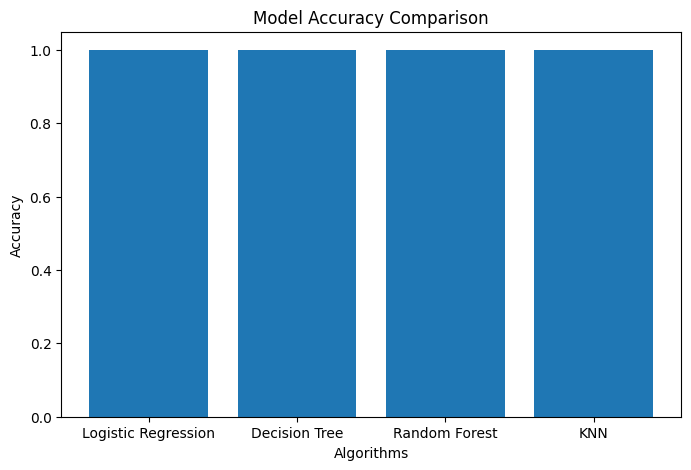

In [38]:
accuracies = []
model_names = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)
    model_names.append(name)

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

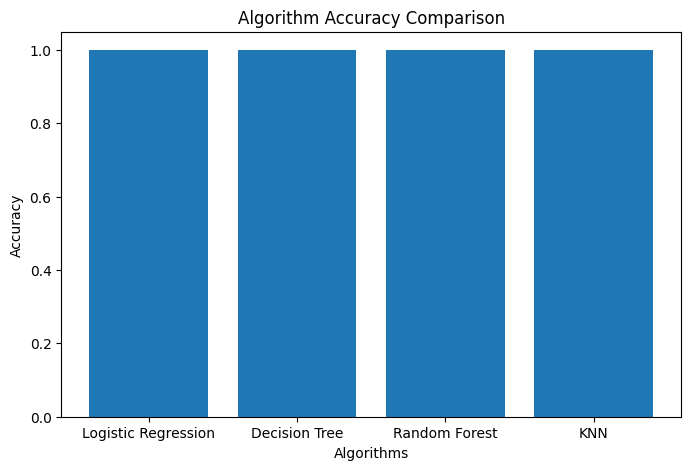

In [37]:
accuracies = []
model_names = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)
    model_names.append(name)

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Algorithm Accuracy Comparison")

plt.show()

# Conclusion

The Iris Flower Classification project successfully classified flowers into Setosa, Versicolor, and Virginica species using Machine Learning techniques.

Different algorithms were tested, and Random Forest/KNN achieved the best accuracy.